# 문항 1 뉴스 기사 데이터 전처리

In [2]:
import pandas as pd
import re

from konlpy.tag import Komoran
from collections import Counter


In [3]:
# https://n.news.naver.com/article/025/0003554066?cds=news_media_pc&type=editn

text = """
인공지능(AI)의 진보에 심혈을 기울이던 개발자들이 잇따라 사표를 내고 있다. AI 기술이 인류를 위협할 수 있다는 우려 때문이다. 구글 딥마인드의 개발자 로버트 오캘러핸은 지난 24일 공개한 사직 이메일에서 “AI를 저렴하게 만들고 AI의 응답 시간을 줄이는 일이 사람들에게 좋다고 생각하지 않는다”고 밝혔다. 앞서 앤트로픽을 떠난 개발자 제이컵 콕슨은 X(옛 트위터)에 “AI를 만드는 사람들이 이번 10년이 끝나기 전 AI가 우리 모두를 죽일 수 있다고 믿는다”고 올렸다.

이들의 우려는 AI 에이전트들이 지시받지 않았는데도 AI 모델·데이터 공유 플랫폼인 허깅페이스를 해킹하며 커졌다. 콕슨은 이 사건이 자신과 동료들에게 큰 충격을 줬다고 월스트리트저널(WSJ)에 말했다. 앤트로픽 직원 일부는 ‘다시는 평온해질 일은 없다’는 노트북 스티커를 붙이는가 하면 외딴 지역 땅을 피난처로 매입하려 했다고 WSJ는 짚었다. 암호화폐 거래소 FTX에선 2023년 재단 관계자가 세계 인구의 50~99.99%가 사망하는 사태에 대비해 태평양 섬나라 나우루를 사 벙커와 피난처를 만드는 걸 논의한 메모가 드러났다.

이런 우려는 2000년대 ‘AI 종말론자(doomer)’로부터 시작됐다. 이들은 AI에 의한 종말을 걱정하면서도 정작 오픈AI와 앤트로픽의 초기 인력으로 참여했다. 여기에 같은 돈과 노력으로 최대한 많은 사람을 돕자는 ‘효과적 이타주의(EA)’ 사상이 결합했다. 하지만 미국 정부 입장은 다르다. WSJ는 “도널드 트럼프 대통령의 일부 측근은 AI 규제를 이끌어내려는 EA 진영의 음모로 콕슨의 사직을 보고 있다”고 전했다.
"""

In [4]:
text = re.sub(r"\s+", " ", text).strip()

## 토큰화

# 문장 단위

In [7]:
sentences = re.split(r"(?<=[.!?])\s+", text)
print(sentences)

['인공지능(AI)의 진보에 심혈을 기울이던 개발자들이 잇따라 사표를 내고 있다.', 'AI 기술이 인류를 위협할 수 있다는 우려 때문이다.', '구글 딥마인드의 개발자 로버트 오캘러핸은 지난 24일 공개한 사직 이메일에서 “AI를 저렴하게 만들고 AI의 응답 시간을 줄이는 일이 사람들에게 좋다고 생각하지 않는다”고 밝혔다.', '앞서 앤트로픽을 떠난 개발자 제이컵 콕슨은 X(옛 트위터)에 “AI를 만드는 사람들이 이번 10년이 끝나기 전 AI가 우리 모두를 죽일 수 있다고 믿는다”고 올렸다.', '이들의 우려는 AI 에이전트들이 지시받지 않았는데도 AI 모델·데이터 공유 플랫폼인 허깅페이스를 해킹하며 커졌다.', '콕슨은 이 사건이 자신과 동료들에게 큰 충격을 줬다고 월스트리트저널(WSJ)에 말했다.', '앤트로픽 직원 일부는 ‘다시는 평온해질 일은 없다’는 노트북 스티커를 붙이는가 하면 외딴 지역 땅을 피난처로 매입하려 했다고 WSJ는 짚었다.', '암호화폐 거래소 FTX에선 2023년 재단 관계자가 세계 인구의 50~99.99%가 사망하는 사태에 대비해 태평양 섬나라 나우루를 사 벙커와 피난처를 만드는 걸 논의한 메모가 드러났다.', '이런 우려는 2000년대 ‘AI 종말론자(doomer)’로부터 시작됐다.', '이들은 AI에 의한 종말을 걱정하면서도 정작 오픈AI와 앤트로픽의 초기 인력으로 참여했다.', '여기에 같은 돈과 노력으로 최대한 많은 사람을 돕자는 ‘효과적 이타주의(EA)’ 사상이 결합했다.', '하지만 미국 정부 입장은 다르다.', 'WSJ는 “도널드 트럼프 대통령의 일부 측근은 AI 규제를 이끌어내려는 EA 진영의 음모로 콕슨의 사직을 보고 있다”고 전했다.']


In [8]:
k = Komoran()
s_tokens = [k.morphs(sentence) for sentence in sentences]
print(s_tokens)

[['인공지능', '(', 'AI', ')', '의', '진보', '에', '심혈', '을', '기울이', '던', '개발자', '들', '이', '잇따르', '아', '사표', '를', '내', '고', '있', '다', '.'], ['AI', '기술', '이', '인류', '를', '위협', '하', 'ㄹ', '수', '있', '다는', '우려', '때문', '이', '다', '.'], ['구글 딥마인드', '의', '개발자', '로버트', '오', '캐', 'ㄹ러', '하', '아', 'ㄴ', '은', '지나', 'ㄴ', '24', '일', '공개', '하', 'ㄴ', '사직', '이', '메일', '에서', '“', 'AI', '를', '저렴', '하', '게', '만들', '고', 'AI', '의', '응답 시간', '을', '줄이', '는', '일', '이', '사람', '들', '에게', '좋', '다고', '생각', '하', '지', '않', '는다', '”', '고', '밝히', '었', '다', '.'], ['앞서', '앤트로픽을', '떠나', 'ㄴ', '개발자', '제이', '컵', '콕스', 'ㄴ', '은', 'X', '(', '옛', '트위터', ')', '에', '“', 'AI', '를', '만들', '는', '사람', '들', '이', '이번', '10', '년', '이', '끝나', '기', '전', 'AI', '가', '우리', '모두', '를', '죽이', 'ㄹ', '수', '있', '다고', '믿', '는다', '”', '고', '올리', '었', '다', '.'], ['이', '들', '의', '우려', '는', 'AI', '에이전트', '들', '이', '지시', '받', '지', '않', '았', '는데', '도', 'AI', '모델', '·', '데이터', '공유', '플랫폼', '이', 'ㄴ', '허깅페이스를', '해킹', '하', '며', '커지', '었', '다', '.'], ['콕스', 'ㄴ', '은', '이',

# 단어 단위

In [9]:
komoran_tokens = k.morphs(text)
print(komoran_tokens)

['인공지능', '(', 'AI', ')', '의', '진보', '에', '심혈', '을', '기울이', '던', '개발자', '들', '이', '잇따르', '아', '사표', '를', '내', '고', '있', '다', '.', 'AI', '기술', '이', '인류', '를', '위협', '하', 'ㄹ', '수', '있', '다는', '우려', '때문', '이', '다', '.', '구글 딥마인드', '의', '개발자', '로버트', '오', '캐', 'ㄹ러', '하', '아', 'ㄴ', '은', '지나', 'ㄴ', '24', '일', '공개', '하', 'ㄴ', '사직', '이', '메일', '에서', '“', 'AI', '를', '저렴', '하', '게', '만들', '고', 'AI', '의', '응답 시간', '을', '줄이', '는', '일', '이', '사람', '들', '에게', '좋', '다고', '생각', '하', '지', '않', '는다', '”', '고', '밝히', '었', '다', '.', '앞서', '앤트로픽을', '떠나', 'ㄴ', '개발자', '제이', '컵', '콕스', 'ㄴ', '은', 'X', '(', '옛', '트위터', ')', '에', '“', 'AI', '를', '만들', '는', '사람', '들', '이', '이번', '10', '년', '이', '끝나', '기', '전', 'AI', '가', '우리', '모두', '를', '죽이', 'ㄹ', '수', '있', '다고', '믿', '는다', '”', '고', '올리', '었', '다', '.', '이', '들', '의', '우려', '는', 'AI', '에이전트', '들', '이', '지시', '받', '지', '않', '았', '는데', '도', 'AI', '모델', '·', '데이터', '공유', '플랫폼', '이', 'ㄴ', '허깅페이스를', '해킹', '하', '며', '커지', '었', '다', '.', '콕스', 'ㄴ', '은', '이', '사건', '이',

In [10]:
kom_tags = k.pos(text)
print(kom_tags)

[('인공지능', 'NNP'), ('(', 'SS'), ('AI', 'SL'), (')', 'SS'), ('의', 'JKG'), ('진보', 'NNG'), ('에', 'JKB'), ('심혈', 'NNG'), ('을', 'JKO'), ('기울이', 'VV'), ('던', 'ETM'), ('개발자', 'NNP'), ('들', 'XSN'), ('이', 'JKS'), ('잇따르', 'VV'), ('아', 'EC'), ('사표', 'NNG'), ('를', 'JKO'), ('내', 'VV'), ('고', 'EC'), ('있', 'VX'), ('다', 'EF'), ('.', 'SF'), ('AI', 'SL'), ('기술', 'NNG'), ('이', 'JKS'), ('인류', 'NNG'), ('를', 'JKO'), ('위협', 'NNG'), ('하', 'XSV'), ('ㄹ', 'ETM'), ('수', 'NNB'), ('있', 'VV'), ('다는', 'ETM'), ('우려', 'NNG'), ('때문', 'NNB'), ('이', 'VCP'), ('다', 'EF'), ('.', 'SF'), ('구글 딥마인드', 'NNP'), ('의', 'JKG'), ('개발자', 'NNP'), ('로버트', 'NNP'), ('오', 'NNG'), ('캐', 'VV'), ('ㄹ러', 'EC'), ('하', 'VX'), ('아', 'EC'), ('ㄴ', 'JX'), ('은', 'JX'), ('지나', 'VV'), ('ㄴ', 'ETM'), ('24', 'SN'), ('일', 'NNB'), ('공개', 'NNG'), ('하', 'XSV'), ('ㄴ', 'ETM'), ('사직', 'NNP'), ('이', 'MM'), ('메일', 'NNP'), ('에서', 'JKB'), ('“', 'SS'), ('AI', 'SL'), ('를', 'JKO'), ('저렴', 'XR'), ('하', 'XSA'), ('게', 'EC'), ('만들', 'VV'), ('고', 'EC'), ('AI', 'SL'), ('의', 'JK

In [ ]:
dic = """
로버트 오캘러핸\tNNP
제이컵 콕슨\tNNP
콕슨\tNNP
구글 딥마인드\tNNP
앤트로픽\tNNP
허깅페이스\tNNP
오픈AI\tNNP
도널드 트럼프\tNNP
이메일\tNNG
"""

with open("user_dic.txt", "w", encoding="utf-8") as f:
    f.write(dic)

komoran_dic = Komoran(userdic="./user_dic.txt", max_heap_size=2048)
print(komoran_dic.morphs(text))

['인공지능', '(', 'AI', ')', '의', '진보', '에', '심혈', '을', '기울이', '던', '개발자', '들', '이', '잇따르', '아', '사표', '를', '내', '고', '있', '다', '.', 'AI', '기술', '이', '인류', '를', '위협', '하', 'ㄹ', '수', '있', '다는', '우려', '때문', '이', '다', '.', '구글 딥마인드', '의', '개발자', '로버트 오캘러핸', '은', '지나', 'ㄴ', '24', '일', '공개', '하', 'ㄴ', '사직', '이메일', '에서', '“', 'AI', '를', '저렴', '하', '게', '만들', '고', 'AI', '의', '응답 시간', '을', '줄이', '는', '일', '이', '사람', '들', '에게', '좋', '다고', '생각', '하', '지', '않', '는다', '”', '고', '밝히', '었', '다', '.', '앞서', '앤트로픽', '을', '떠나', 'ㄴ', '개발자', '제이컵 콕슨', '은', 'X', '(', '옛', '트위터', ')', '에', '“', 'AI', '를', '만들', '는', '사람', '들', '이', '이번', '10', '년', '이', '끝나', '기', '전', 'AI', '가', '우리', '모두', '를', '죽이', 'ㄹ', '수', '있', '다고', '믿', '는다', '”', '고', '올리', '었', '다', '.', '이', '들', '의', '우려', '는', 'AI', '에이전트', '들', '이', '지시', '받', '지', '않', '았', '는데', '도', 'AI', '모델', '·', '데이터', '공유', '플랫폼', '이', 'ㄴ', '허깅페이스', '를', '해킹', '하', '며', '커지', '었', '다', '.', '콕슨', '은', '이', '사건', '이', '자신', '과', '동료', '들', '에게', '크', 'ㄴ', 

In [11]:
s_tokens = [k.morphs(sentence) for sentence in sentences]
komoran_tokens = [token for tokens in s_tokens for token in tokens]
kom_tags = [
    pair
    for sentence in sentences
    for pair in k.pos(sentence)
]

## 품사 부착

In [ ]:
pos_dist = pd.DataFrame(Counter([t for _, t in kom_tags]).most_common(), columns=["품사", "빈도"])
pos_dist

,품사,빈도
0,NNG,68
1,NNP,35
2,VV,30
3,EC,25
4,SS,22
5,ETM,21
6,JX,20
7,SL,19
8,JKO,16
9,JKB,14


In [20]:
keep_tags = {"NNG", "NNP", "SL"}

stopwords = {"일부", "이번", "자신", "모두", "정작", "최대한"}

clean_tokens = [
    word
    for word, tag in kom_tags
    if tag in keep_tags and word not in stopwords
]

word_counts = Counter(clean_tokens)

freq_df = pd.DataFrame(
    word_counts.most_common(20),
    columns=["단어", "빈도"]
)

display(freq_df)

,단어,빈도
0,AI,12
1,개발자,3
2,우려,3
3,사람,3
4,콕스,3
5,WSJ,3
6,사직,2
7,피난처,2
8,EA,2
9,인공지능,1


## 시각화

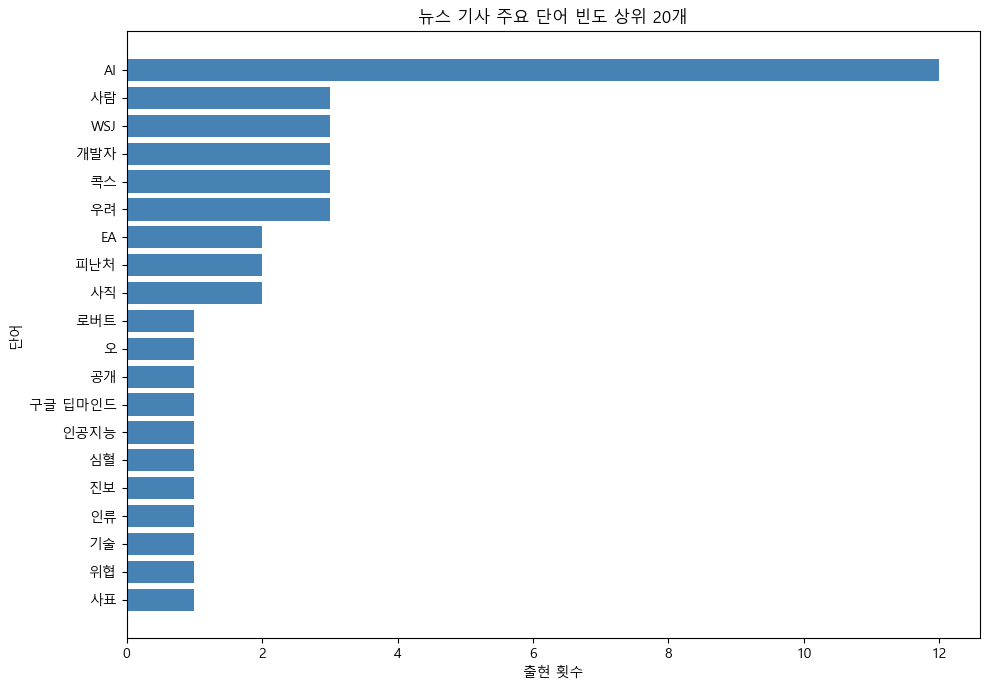

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"

plot_df = freq_df.sort_values("빈도", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(plot_df["단어"], plot_df["빈도"], color="steelblue")
ax.set_title("뉴스 기사 주요 단어 빈도 상위 20개")
ax.set_xlabel("출현 횟수")
ax.set_ylabel("단어")

plt.tight_layout()
plt.show()

## 전처리 결과에 대한 고찰

1. Komaran을 사용해 tokenization 하였고, 이 과정에서 에러들을 발견해 user_dic.txt을 만들어 처리했습니다. 또한, re 라이브러리를 사용해 전처리를 했습니다. 

2. 원형 복원이 필요한 이유는 한국어는 같은 단어가 여러가지 비슷한 형태로 많이 사용되기 때문에 같은 단어라도 다른 형태로 존재해 상위건에 오르지 못하기 때문입니다.

3. 빈도와 태그의 유형에 따라 고려한 후 구성해야 합니다.

4. 단어의 수가 늘어나고 더욱 랜덤한 단어가 늘어나 성능이 떨어집니다.